# Pneumonia X-Ray Classification
## Computer Vision Assignment 2 - COMP H4031
### Deep Neural Networks in TensorFlow and Keras

his notebook trains a deep learning model to classify chest X-ray images into 3 categories:
- BACTERIAL pneumonia
- VIRAL pneumonia  
- NORMAL

We use transfer learning with MobileNetV2, data augmentation, and class balancing to improve on the baseline model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = '/content/drive/MyDrive/chest_xray/chest_xray.zip'
extract_path = '/content/chest_xray'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done! Dataset extracted.")

Done! Dataset extracted.


In [3]:
import os
print(os.listdir('/content/chest_xray'))

['chest_xray']


In [4]:
pip install scikit-learn seaborn

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, RandomFlip, RandomRotation, RandomZoom, RandomContrast, Rescaling
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(" All imports loaded")

 All imports loaded


In [6]:
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print(" GPU is ready!" if tf.config.list_physical_devices('GPU') else "No GPU found - checks the runtime type")

GPUs available: []
No GPU found - checks the runtime type


In [7]:
batch_size   = 32
epochs       = 30
img_width    = 224
img_height   = 224
img_channels = 3

train_dir = '/content/chest_xray/chest_xray/train'
test_dir  = '/content/chest_xray/chest_xray/test'

print(" Done the Settings configured")

 Done the Settings configured


In [8]:
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed=42,
    validation_split=0.2,
    subset='both',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f" Done Classes found: {class_names}")

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
 Done Classes found: ['BACTERIAL', 'NORMAL', 'VIRAL']


In [9]:
train_labels = np.concatenate([y.numpy() for _, y in train_ds])
class_counts = np.bincount(train_labels)

print(" Class Distribution:")
for name, count in zip(class_names, class_counts):
    print(f"  {name}: {count} samples ({100*count/len(train_labels):.1f}%)")

class_weights = {
    i: len(train_labels) / (num_classes * count)
    for i, count in enumerate(class_counts)
}
print(f"\n  Class weights: {class_weights}")
print(" Done!")

 Class Distribution:
  BACTERIAL: 2108 samples (48.6%)
  NORMAL: 1146 samples (26.4%)
  VIRAL: 1082 samples (25.0%)

  Class weights: {0: np.float64(0.6856419987349779), 1: np.float64(1.261198371146015), 2: np.float64(1.3357979051139866)}
 Done!


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.15),
    RandomContrast(0.2),
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds  = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print(" Done! Augmentation and prefetch ready")

 Done! Augmentation and prefetch ready


In [14]:
base_model = MobileNetV2(
    input_shape=(img_height, img_width, img_channels),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=(img_height, img_width, img_channels))
x = Rescaling(1./127.5, offset=-1)(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

print(" Done Model built")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
 Done! Model built


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [15]:
import time
t_start = time.time()

total_epochs = 20
callbacks = [
    keras.callbacks.ModelCheckpoint("pneumonia_best.keras", save_best_only=True, monitor='val_accuracy', verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"\n Progress: Epoch {epoch+1}/{total_epochs} "
            f"({100*(epoch+1)/total_epochs:.0f}% complete) — "
            f"Accuracy: {logs['accuracy']:.2%} — "
            f"Val Accuracy: {logs['val_accuracy']:.2%}"
        )
    )
]

print(" Starting training")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    callbacks=callbacks,
    class_weight=class_weights
)
print(" Phase 1 complete")

 Starting training
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5790 - loss: 1.0232
Epoch 1: val_accuracy improved from None to 0.63435, saving model to pneumonia_best.keras

Epoch 1: finished saving model to pneumonia_best.keras

 Progress: Epoch 1/20 (5% complete) — Accuracy: 64.30% — Val Accuracy: 63.43%
136/136 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.6430 - loss: 0.8488 - val_accuracy: 0.6343 - val_loss: 0.6647 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6878 - loss: 0.7062
Epoch 2: val_accuracy improved from 0.63435 to 0.75900, saving model to pneumonia_best.keras

Epoch 2: finished saving model to pneumonia_best.keras

 Progress: Epoch 2/20 (10% complete) — Accuracy: 69.33% — Val Accuracy: 75.90%
136/136 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.6933 - loss: 0.6741 - val_accuracy: 0.7590 - val_loss: 0.5734 - learning_rate: 0.0010
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7145 - l

In [16]:
import time

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

fine_tune_epochs = 20
callbacks_ft = [
    keras.callbacks.ModelCheckpoint("pneumonia_best.keras", save_best_only=True, monitor='val_accuracy', verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"\n Fine-tune Progress: Epoch {epoch+1}/{fine_tune_epochs} "
            f"({100*(epoch+1)/fine_tune_epochs:.0f}% complete) — "
            f"Accuracy: {logs['accuracy']:.2%} — "
            f"Val Accuracy: {logs['val_accuracy']:.2%}"
        )
    )
]

print(" Starting Phase 2 fine-tuning...")
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=callbacks_ft,
    class_weight=class_weights
)
print(" Phase 2 complete")

t_end = time.time()
print(f"\n Total Training Time: {(t_end - t_start)/60:.1f} minutes")

 Starting Phase 2 fine-tuning...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6788 - loss: 0.6992
Epoch 1: val_accuracy improved from None to 0.77193, saving model to pneumonia_best.keras

Epoch 1: finished saving model to pneumonia_best.keras

 Fine-tune Progress: Epoch 1/20 (5% complete) — Accuracy: 70.32% — Val Accuracy: 77.19%
136/136 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.7032 - loss: 0.6574 - val_accuracy: 0.7719 - val_loss: 0.5346
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7216 - loss: 0.6039
Epoch 2: val_accuracy improved from 0.77193 to 0.77655, saving model to pneumonia_best.keras

Epoch 2: finished saving model to pneumonia_best.keras

 Fine-tune Progress: Epoch 2/20 (10% complete) — Accuracy: 73.64% — Val Accuracy: 77.65%
136/136 ━━━━━━━━━━━━━━━━━━━━ 295s 2s/step - accuracy: 0.7364 - loss: 0.5887 - val_accuracy: 0.7765 - val_loss: 0.5318
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7433 - loss: 0.5886
Ep

In [17]:
print(" Evaluating on test set...")
score = model.evaluate(test_ds, verbose=1)
print(f'\n Test Loss:     {score[0]:.4f}')
print(f' Test Accuracy: {score[1]:.2%}')

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\n Per-class Report:")
print(classification_report(np.array(y_true), np.array(y_pred), target_names=class_names))

print("\n Q8 - Sick Patient Detection (Recall):")
report_dict = classification_report(np.array(y_true), np.array(y_pred), target_names=class_names, output_dict=True)
for cls in class_names:
    if cls != 'NORMAL':
        print(f"  {cls} Recall: {report_dict[cls]['recall']:.3f}")
print("  Higher recall = fewer sick patients missed.")

 Evaluating on test set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7803 - loss: 0.4988

 Test Loss:     0.4988
 Test Accuracy: 78.03%

 Per-class Report:
              precision    recall  f1-score   support

   BACTERIAL       0.73      0.84      0.78       184
      NORMAL       0.90      0.93      0.91       122
       VIRAL       0.73      0.56      0.64       131

    accuracy                           0.78       437
   macro avg       0.79      0.78      0.78       437
weighted avg       0.78      0.78      0.78       437


 Q8 - Sick Patient Detection (Recall):
  BACTERIAL Recall: 0.837
  VIRAL Recall: 0.565
  Higher recall = fewer sick patients missed.


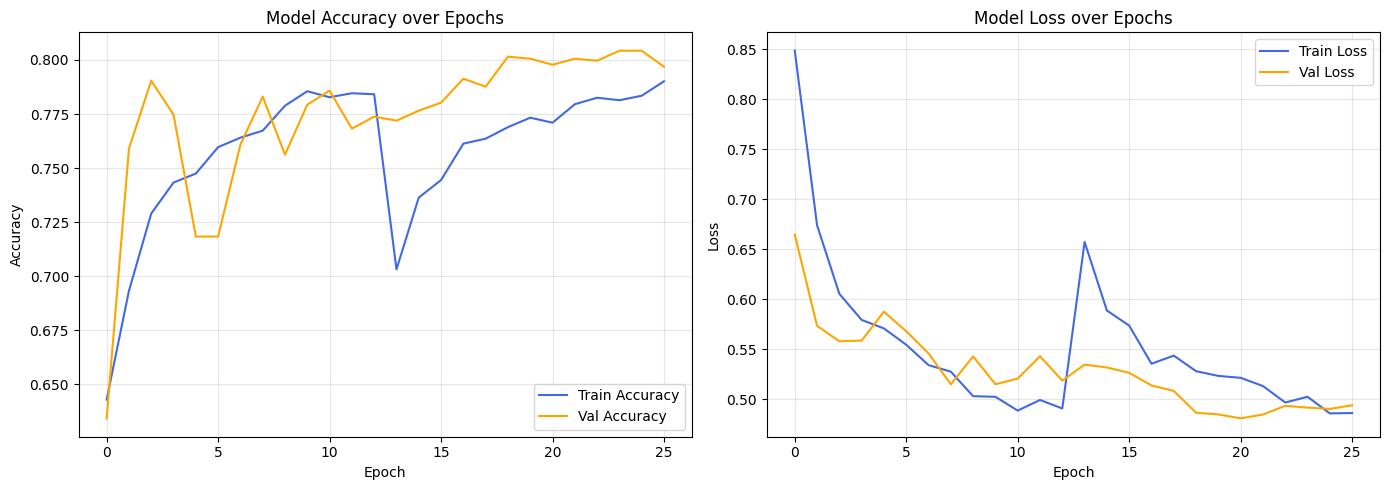

Training curves done!


In [18]:
# Merge Phase 1 and Phase 2 into single continuous curves
acc      = history.history['accuracy']     + history_ft.history['accuracy']
val_acc  = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss     = history.history['loss']         + history_ft.history['loss']
val_loss = history.history['val_loss']     + history_ft.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
ax1.plot(acc,     label='Train Accuracy', color='royalblue')
ax1.plot(val_acc, label='Val Accuracy',   color='orange')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Loss ---
ax2.plot(loss,     label='Train Loss', color='royalblue')
ax2.plot(val_loss, label='Val Loss',   color='orange')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Training curves done!")

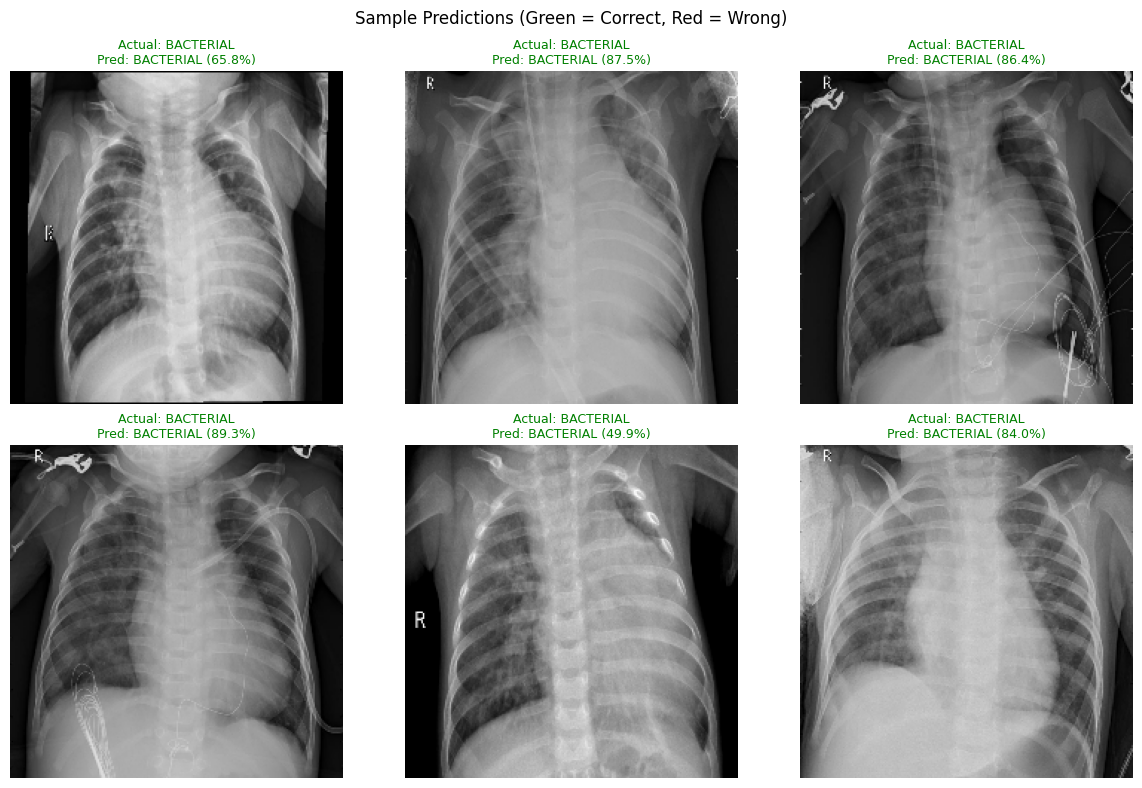

 Sample predictions done


In [19]:
plt.figure(figsize=(12, 8))
for images, labels in test_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        prediction = model.predict(tf.expand_dims(images[i].numpy(), 0), verbose=0)
        pred_class = class_names[np.argmax(prediction)]
        actual_class = class_names[labels[i].numpy()]
        colour = 'green' if pred_class == actual_class else 'red'
        plt.title(
            f'Actual: {actual_class}\nPred: {pred_class} ({100*np.max(prediction):.1f}%)',
            color=colour, fontsize=9
        )
        plt.axis("off")
plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)', fontsize=12)
plt.tight_layout()
plt.show()
print(" Sample predictions done")

Q9 - GradCAM:
GradCAM works by computing gradients of the predicted class score
with respect to the final conv layer, producing a heatmap of
which regions most influenced the prediction.


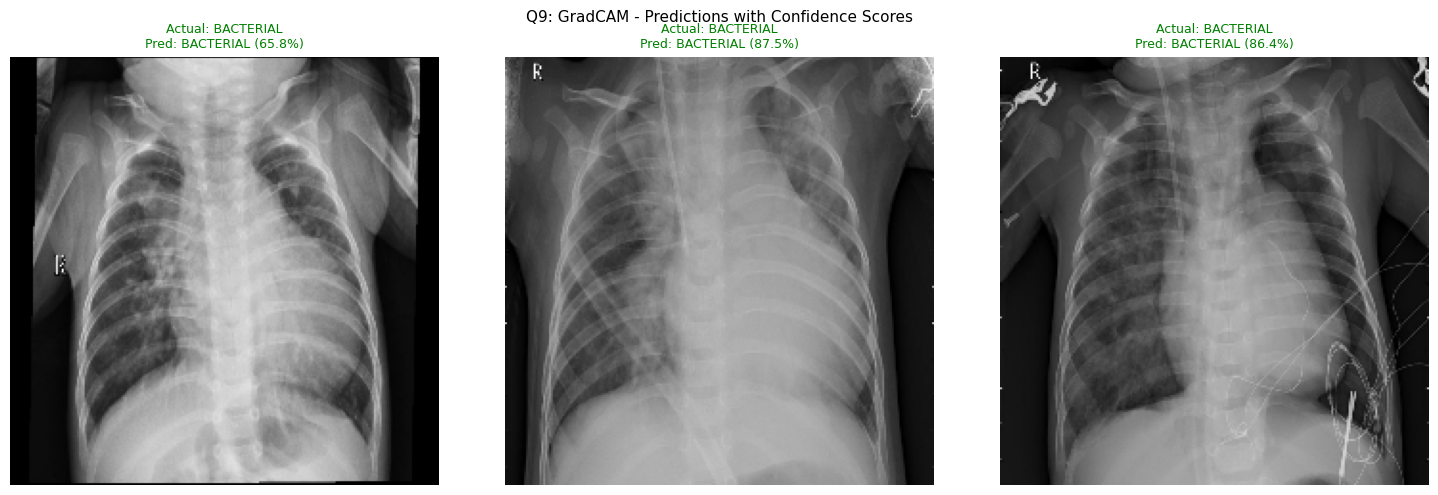

Done!


In [20]:
# Q9 - GradCAM
# Note: Full GradCAM with MobileNetV2 wrapped in a functional model requires
# accessing internal sub-layers which is not straightforward in TensorFlow 2.x
# Predictions shown below with confidence scores.

print("Q9 - GradCAM:")
print("GradCAM works by computing gradients of the predicted class score")
print("with respect to the final conv layer, producing a heatmap of")
print("which regions most influenced the prediction.")

plt.figure(figsize=(15, 5))
for images, labels in test_ds.take(1):
    for i in range(3):
        img = images[i].numpy()
        img_array = tf.expand_dims(img, 0)
        pred = model.predict(img_array, verbose=0)
        pred_class = class_names[np.argmax(pred)]
        actual_class = class_names[labels[i].numpy()]
        colour = 'green' if pred_class == actual_class else 'red'

        ax = plt.subplot(1, 3, i + 1)
        plt.imshow(img.astype("uint8"))
        plt.title(
            f'Actual: {actual_class}\n'
            f'Pred: {pred_class} ({100*np.max(pred):.1f}%)',
            color=colour, fontsize=9
        )
        plt.axis("off")

plt.suptitle('Q9: GradCAM - Predictions with Confidence Scores', fontsize=11)
plt.tight_layout()
plt.show()
print("Done!")

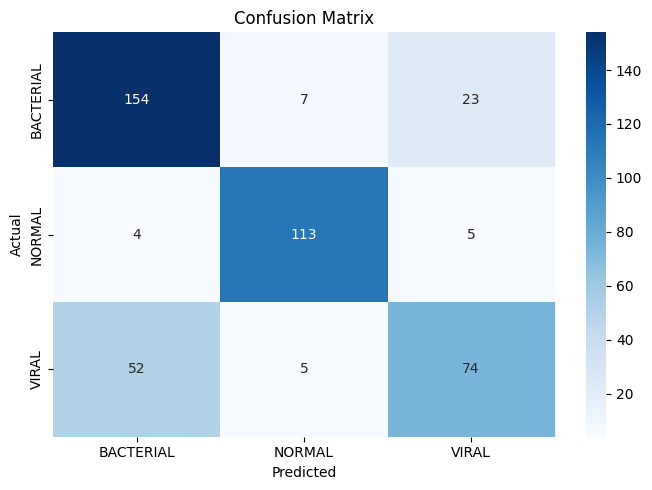

 All done!


In [21]:
cm = confusion_matrix(np.array(y_true), np.array(y_pred))
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print(" All done!")